Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drug 데이터 엔트로피: 1.9688
Feature 0의 정보 이득: 0.7036
Feature 1의 정보 이득: 0.0077
Feature 2의 정보 이득: 0.6201
Feature 3의 정보 이득: 0.0931
Feature 4의 정보 이득: 1.9588


<ipython-input-4-a0aa5236083e>:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex']=df['Sex'].replace({'F':2, 'M':1})
<ipython-input-4-a0aa5236083e>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BP']=df['BP'].replace({'LOW':1, 'NORMAL':0, 'HIGH':2})
<ipython-input-4-a0aa5236083e>:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option

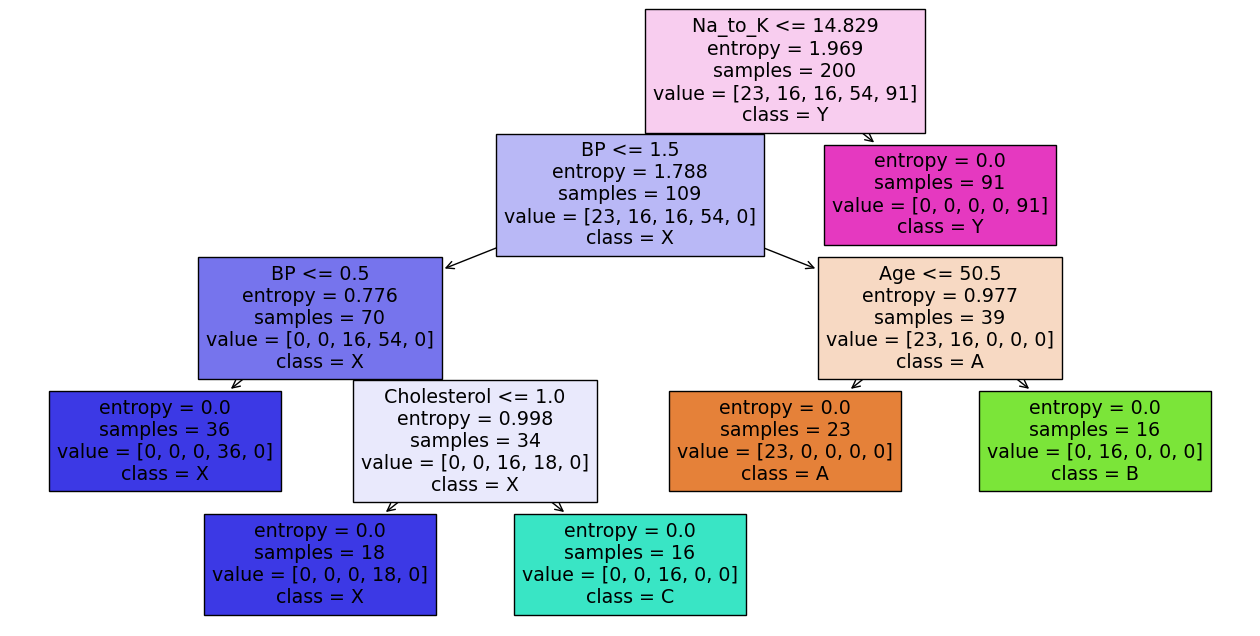

In [ ]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
import pandas as pd
from google.colab import drive

# Information entropy 함수 정의
def entropy(y):
    # y의 고유값과 각각의 빈도수 계산
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()  # pk
    # 엔트로피 계산
    return -np.sum(p * np.log2(p))

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/drug200.csv', usecols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'])

df['Sex']=df['Sex'].replace({'F':2, 'M':1})
df['BP']=df['BP'].replace({'LOW':1, 'NORMAL':0, 'HIGH':2})
df['Cholesterol']=df['Cholesterol'].replace({'NORMAL':0, 'HIGH':2, 'LOW':1})
df['Drug']=df['Drug'].replace({'drugA':1, 'drugB':2, 'drugC':3, 'drugX':4, 'drugY':5})
df.head()
df = df.to_numpy()


X = df[:,0:5]
y = df[:,5]

# 전체 데이터의 엔트로피 계산
total_entropy = entropy(y)
print(f"Drug 데이터 엔트로피: {total_entropy:.4f}")

#  피처별(나이, 성별, 혈압, 콜레스테롤, 나트륨-칼륨) 정보 이득(Information Gain) 계산
for feature_idx in range(X.shape[1]):
    feature_values = np.unique(X[:, feature_idx])
    feature_entropy = 0
    for value in feature_values:
        # 해당 값에 해당하는 데이터 인덱스
        idx = X[:, feature_idx] == value
        subset_y = y[idx]
        weight = len(subset_y) / len(y)
        subset_entropy = entropy(subset_y)
        feature_entropy += weight * subset_entropy
    info_gain = total_entropy - feature_entropy
    print(f"Feature {feature_idx}의 정보 이득: {info_gain:.4f}")


clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X, y)

# Decision Tree for binary classifier
plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], class_names=['A', 'B', 'C', 'X', 'Y'], filled=True)
plt.show()